# Figure R3: Thinks harder, not longer (question-level evidence)

**Panels:**
- **a.** Omni-MATH paired scatter (both-correct questions)
- **b.** GPQA Diamond paired scatter
- **c.** Outcome transition bars (5 categories)
- **d.** Token savings by difficulty tier

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath, amssymb}"

cm = 1 / 2.54

COLOR_O1 = '#0072B2'
COLOR_O3 = '#E69F00'

# Difficulty tier colors (pink/mauve palette)
TIER_COLORS = ['#cc78bc', '#d899cb', '#e4b9da', '#f0daea']  # pink/mauve gradient

## Data Loading

In [3]:
def load_gpt5mini_judge(filepath):
    """Load correctness from GPT-5-mini batch API judge results."""
    results = []
    with open(filepath) as f:
        for line in f:
            entry = json.loads(line)
            body = entry['response']['body']
            correct = False
            for o in body['output']:
                if o['type'] == 'message':
                    parsed = json.loads(o['content'][0]['text'])
                    correct = parsed['correct'] == 'yes'
                    break
            results.append(correct)
    return results


def extract_gpqa_tokens(entry):
    """Extract reasoning tokens from GPQA batch API result."""
    usage = entry['response']['body']['usage']
    return usage.get('completion_tokens_details', {}).get('reasoning_tokens', 0)


# ============================================================
# Omni-MATH (o1-mini vs o3-mini)
# ============================================================
with open('data/omni_math/reasoning_models/responses_o1.jsonl') as f:
    omni_o1_raw = [json.loads(l) for l in f]
with open('data/omni_math/reasoning_models/responses_o3.jsonl') as f:
    omni_o3_raw = [json.loads(l) for l in f]

omni_o1_correct = load_gpt5mini_judge('data/omni_math/reasoning_models/judge_results_o1.jsonl')
omni_o3_correct = load_gpt5mini_judge('data/omni_math/reasoning_models/judge_results_o3.jsonl')

omni_o1 = pd.DataFrame([{
    'problem': r['problem'],
    'correct': omni_o1_correct[i],
    'reasoning_tokens': r['reasoning_tokens'],
    'difficulty': r['difficulty'],
} for i, r in enumerate(omni_o1_raw)])

omni_o3 = pd.DataFrame([{
    'problem': r['problem'],
    'correct': omni_o3_correct[i],
    'reasoning_tokens': r['reasoning_tokens'],
} for i, r in enumerate(omni_o3_raw)])

# Deduplicate before merging — some problems appear multiple times in response files
print(f'Omni-MATH o1 before dedup: {len(omni_o1)} (unique: {omni_o1["problem"].nunique()})')
print(f'Omni-MATH o3 before dedup: {len(omni_o3)} (unique: {omni_o3["problem"].nunique()})')
omni_o1 = omni_o1.drop_duplicates(subset='problem', keep='first')
omni_o3 = omni_o3.drop_duplicates(subset='problem', keep='first')

omni_merged = omni_o1.merge(omni_o3, on='problem', suffixes=('_o1', '_o3'))
print(f'Omni-MATH matched after dedup: {len(omni_merged)} questions')

# ============================================================
# GPQA Diamond (o1 vs o3 — full models, not mini)
# ============================================================
with open('data/gpqa/reasoning_models/results_o1.jsonl') as f:
    gpqa_o1_raw = [json.loads(l) for l in f]
with open('data/gpqa/reasoning_models/results_o3.jsonl') as f:
    gpqa_o3_raw = [json.loads(l) for l in f]

gpqa_o1_correct = load_gpt5mini_judge('data/gpqa/reasoning_models/judge_results_o1.jsonl')
gpqa_o3_correct = load_gpt5mini_judge('data/gpqa/reasoning_models/judge_results_o3.jsonl')

gpqa_o1 = pd.DataFrame([{
    'correct': gpqa_o1_correct[i],
    'reasoning_tokens': extract_gpqa_tokens(r),
} for i, r in enumerate(gpqa_o1_raw)])

gpqa_o3 = pd.DataFrame([{
    'correct': gpqa_o3_correct[i],
    'reasoning_tokens': extract_gpqa_tokens(r),
} for i, r in enumerate(gpqa_o3_raw)])

# GPQA: aligned by index (same 198 questions)
gpqa_merged = pd.DataFrame({
    'correct_o1': gpqa_o1['correct'],
    'correct_o3': gpqa_o3['correct'],
    'reasoning_tokens_o1': gpqa_o1['reasoning_tokens'],
    'reasoning_tokens_o3': gpqa_o3['reasoning_tokens'],
})

# Verify model identities
print(f'\nGPQA o1 model: {gpqa_o1_raw[0]["response"]["body"]["model"]}')
print(f'GPQA o3 model: {gpqa_o3_raw[0]["response"]["body"]["model"]}')
print(f'GPQA matched: {len(gpqa_merged)} questions')

Omni-MATH o1 before dedup: 4426 (unique: 4404)
Omni-MATH o3 before dedup: 4424 (unique: 4402)
Omni-MATH matched after dedup: 4400 questions

GPQA o1 model: o1-2024-12-17
GPQA o3 model: o3-2025-04-16
GPQA matched: 198 questions


In [4]:
# ============================================================
# Build both-correct intersections (for scatter plots)
# ============================================================

# Omni-MATH: both correct, nonzero tokens
omni_both = omni_merged[omni_merged['correct_o1'] & omni_merged['correct_o3']].copy()
omni_both = omni_both[(omni_both['reasoning_tokens_o1'] > 0) & (omni_both['reasoning_tokens_o3'] > 0)].copy()
omni_both['ratio'] = omni_both['reasoning_tokens_o1'] / omni_both['reasoning_tokens_o3']

# Assign difficulty tiers via qcut
omni_both['tier'] = pd.qcut(omni_both['difficulty'], 4, labels=['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4'])

print(f'Omni-MATH both-correct: {len(omni_both)}, median ratio={omni_both["ratio"].median():.2f}')
print(f'  o1 >= o3 tokens (above diagonal): {(omni_both["ratio"] >= 1).mean()*100:.1f}%')

# GPQA: both correct, nonzero tokens
gpqa_both = gpqa_merged[gpqa_merged['correct_o1'] & gpqa_merged['correct_o3']].copy()
gpqa_both = gpqa_both[(gpqa_both['reasoning_tokens_o1'] > 0) & (gpqa_both['reasoning_tokens_o3'] > 0)].copy()
gpqa_both['ratio'] = gpqa_both['reasoning_tokens_o1'] / gpqa_both['reasoning_tokens_o3']

print(f'GPQA both-correct: {len(gpqa_both)}, median ratio={gpqa_both["ratio"].median():.2f}')
print(f'  o1 >= o3 tokens (above diagonal): {(gpqa_both["ratio"] >= 1).mean()*100:.1f}%')

Omni-MATH both-correct: 2485, median ratio=1.14
  o1 >= o3 tokens (above diagonal): 63.3%
GPQA both-correct: 140, median ratio=1.29
  o1 >= o3 tokens (above diagonal): 66.4%


In [5]:
# ============================================================
# Build 5-category outcome classification
# ============================================================

def classify_outcomes(merged_df, name, has_tokens_cols=True):
    """Classify each question into 5 outcome categories."""
    tok_o1 = 'reasoning_tokens_o1'
    tok_o3 = 'reasoning_tokens_o3'
    
    both_correct = merged_df['correct_o1'] & merged_df['correct_o3']
    o3_only = ~merged_df['correct_o1'] & merged_df['correct_o3']
    o1_only = merged_df['correct_o1'] & ~merged_df['correct_o3']
    both_wrong = ~merged_df['correct_o1'] & ~merged_df['correct_o3']
    
    # Both correct: split by who used fewer tokens
    bc_o3_fewer = both_correct & (merged_df[tok_o3] <= merged_df[tok_o1])
    bc_o3_more = both_correct & (merged_df[tok_o3] > merged_df[tok_o1])
    
    counts = {
        'Both correct,\no3 fewer tokens': bc_o3_fewer.sum(),
        'Both correct,\no3 more tokens': bc_o3_more.sum(),
        'Only o3\ncorrect': o3_only.sum(),
        'Only o1\ncorrect': o1_only.sum(),
        'Both\nwrong': both_wrong.sum(),
    }
    total = len(merged_df)
    pcts = {k: v / total * 100 for k, v in counts.items()}
    
    print(f'{name} ({total} questions):')
    for k, v in counts.items():
        print(f'  {k.replace(chr(10), " ")}: {v} ({pcts[k]:.1f}%)')
    
    return counts, pcts

omni_counts, omni_pcts = classify_outcomes(omni_merged, 'Omni-MATH')
gpqa_counts, gpqa_pcts = classify_outcomes(gpqa_merged, 'GPQA')

Omni-MATH (4400 questions):
  Both correct, o3 fewer tokens: 1578 (35.9%)
  Both correct, o3 more tokens: 916 (20.8%)
  Only o3 correct: 636 (14.5%)
  Only o1 correct: 180 (4.1%)
  Both wrong: 1090 (24.8%)
GPQA (198 questions):
  Both correct, o3 fewer tokens: 93 (47.0%)
  Both correct, o3 more tokens: 47 (23.7%)
  Only o3 correct: 20 (10.1%)
  Only o1 correct: 8 (4.0%)
  Both wrong: 30 (15.2%)


In [6]:
# ============================================================
# Token savings by difficulty tier (panel d)
# ============================================================

tier_stats = []
for tier in ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']:
    subset = omni_both[omni_both['tier'] == tier]
    ratios = subset['ratio']
    median_ratio = ratios.median()
    q25 = ratios.quantile(0.25)
    q75 = ratios.quantile(0.75)
    tier_stats.append({'tier': tier, 'median': median_ratio, 'q25': q25, 'q75': q75, 'n': len(subset)})
    print(f'{tier}: n={len(subset)}, median ratio={median_ratio:.2f} (IQR: {q25:.2f}-{q75:.2f})')

tier_stats_df = pd.DataFrame(tier_stats)

Tier 1: n=702, median ratio=1.00 (IQR: 0.67-1.50)
Tier 2: n=584, median ratio=1.17 (IQR: 0.81-1.73)
Tier 3: n=591, median ratio=1.26 (IQR: 0.86-1.91)
Tier 4: n=608, median ratio=1.22 (IQR: 0.74-2.12)


## Figure

/var/folders/2b/wwf70wd17zb31hbys4zvv1c80000gn/T/ipykernel_67593/2988397903.py:17: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(omni_both['reasoning_tokens_o3'], omni_both['reasoning_tokens_o1'],
/var/folders/2b/wwf70wd17zb31hbys4zvv1c80000gn/T/ipykernel_67593/2988397903.py:42: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(gpqa_both['reasoning_tokens_o3'], gpqa_both['reasoning_tokens_o1'],


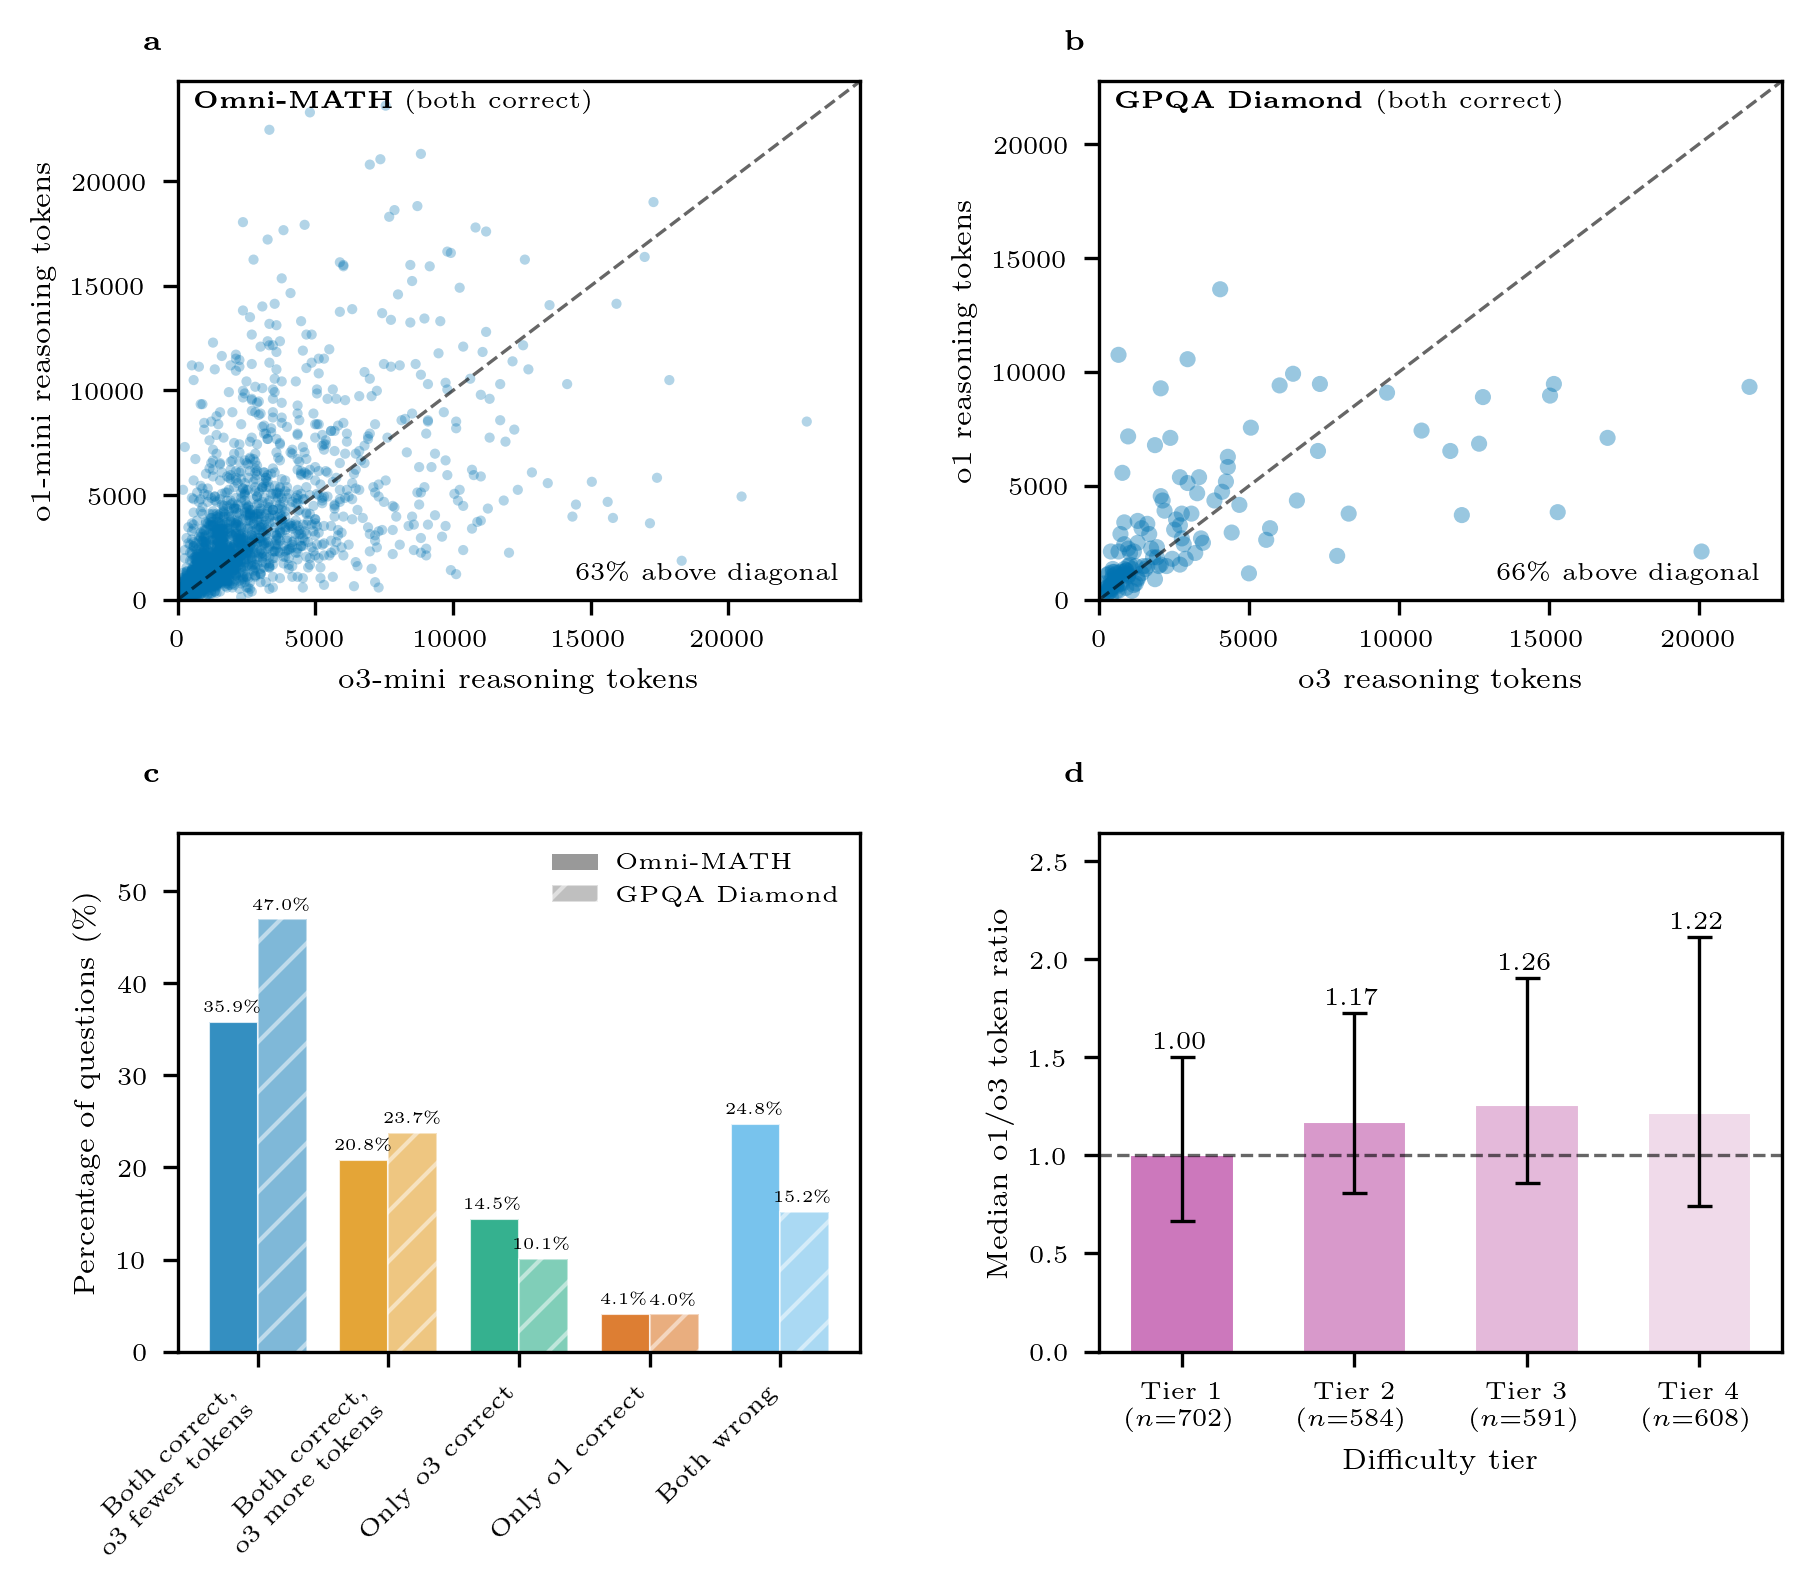

In [8]:
import seaborn as sns
palette = sns.color_palette('colorblind')

fig, axes = plt.subplot_mosaic(
    [['scatter_omni', 'scatter_gpqa'],
     ['bars', 'tier_ratio']],
    figsize=(6.9, 5.5),
    gridspec_kw={'wspace': 0.35, 'hspace': 0.45},
    dpi=300,
)

# ============================================================
# Panel a: Omni-MATH paired scatter (o1-mini vs o3-mini)
# ============================================================
ax = axes['scatter_omni']

ax.scatter(omni_both['reasoning_tokens_o3'], omni_both['reasoning_tokens_o1'],
           c=palette[0], s=6, alpha=0.3, edgecolors='none', rasterized=True)

# Diagonal y=x line
lims = [0, max(omni_both['reasoning_tokens_o1'].max(), omni_both['reasoning_tokens_o3'].max()) * 1.05]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.6, zorder=5)

pct_above = (omni_both['ratio'] >= 1).mean() * 100
ax.text(0.97, 0.03, rf'{pct_above:.0f}\% above diagonal',
        ha='right', va='bottom', transform=ax.transAxes, fontsize=6,
        bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.text(-0.05, 1.1, r'\textbf{a}', fontsize=7, va='top', ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))

ax.set_xlabel('o3-mini reasoning tokens', fontsize=7)
ax.set_ylabel('o1-mini reasoning tokens', fontsize=7)
ax.text(0.025, 0.95, rf'\textbf{{Omni-MATH}} (both correct)', fontsize=6, ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.tick_params(axis='both', labelsize=6)
ax.set_xlim(lims)
ax.set_ylim(lims)

# ============================================================
# Panel b: GPQA Diamond paired scatter (o1 vs o3, full models)
# ============================================================
ax = axes['scatter_gpqa']

ax.scatter(gpqa_both['reasoning_tokens_o3'], gpqa_both['reasoning_tokens_o1'],
           c=palette[0], s=15, alpha=0.4, edgecolors='none', rasterized=True)

lims_g = [0, max(gpqa_both['reasoning_tokens_o1'].max(), gpqa_both['reasoning_tokens_o3'].max()) * 1.05]
ax.plot(lims_g, lims_g, 'k--', lw=0.8, alpha=0.6, zorder=5)

pct_above_g = (gpqa_both['ratio'] >= 1).mean() * 100
ax.text(0.97, 0.03, rf'{pct_above_g:.0f}\% above diagonal',
        ha='right', va='bottom', transform=ax.transAxes, fontsize=6,
        bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.text(-0.05, 1.1, r'\textbf{b}', fontsize=7, va='top', ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))

ax.set_xlabel('o3 reasoning tokens', fontsize=7)
ax.set_ylabel('o1 reasoning tokens', fontsize=7)
ax.text(0.025, 0.95, rf'\textbf{{GPQA Diamond}} (both correct)', fontsize=6, ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.tick_params(axis='both', labelsize=6)
ax.set_xlim(lims_g)
ax.set_ylim(lims_g)

# ============================================================
# Panel c: Outcome transition bars
# ============================================================
ax = axes['bars']

categories = list(omni_counts.keys())
# Shorter labels to avoid overlap
short_labels = [
    'Both correct,\no3 fewer tokens',
    'Both correct,\no3 more tokens',
    'Only o3 correct',
    'Only o1 correct',
    'Both wrong',
]
bar_colors = [palette[0], palette[1], palette[2], palette[3], palette[9]]

x = np.arange(len(categories))
width = 0.375

omni_vals = [omni_pcts[k] for k in categories]
gpqa_vals = [gpqa_pcts[k] for k in categories]

bars1 = ax.bar(x - width/2, omni_vals, width, label='Omni-MATH', color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.8)
bars2 = ax.bar(x + width/2, gpqa_vals, width, label='GPQA Diamond', color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.5, hatch='//')

# Add percentage labels
for bar, val in zip(bars1, omni_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            rf'{val:.1f}\%', ha='center', va='bottom', fontsize=4)
for bar, val in zip(bars2, gpqa_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            rf'{val:.1f}\%', ha='center', va='bottom', fontsize=4)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=5, ha='right', rotation=45)
ax.set_ylabel(r'Percentage of questions (\%)', fontsize=7)
ax.set_ylim(0, max(max(omni_vals), max(gpqa_vals)) * 1.2)
ax.text(-0.05, 1.1, r'\textbf{c}', fontsize=7, ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.tick_params(axis='both', labelsize=6)

# Custom legend for benchmarks
legend_elements = [
    patches.Patch(facecolor='grey', alpha=0.8, label='Omni-MATH'),
    patches.Patch(facecolor='grey', alpha=0.5, hatch='//', label='GPQA Diamond', edgecolor='white', linewidth=0.5),
]
ax.legend(handles=legend_elements, fontsize=5.5, frameon=True, loc='upper right',
          framealpha=0.8, edgecolor='none')

# ============================================================
# Panel d: Token savings by difficulty tier (bar + IQR)
# ============================================================
ax = axes['tier_ratio']

x_tiers = np.arange(len(tier_stats_df))
bars = ax.bar(x_tiers, tier_stats_df['median'], width=0.6,
              color=TIER_COLORS, edgecolor='white', linewidth=0.5)

# IQR error bars
yerr_low = tier_stats_df['median'] - tier_stats_df['q25']
yerr_high = tier_stats_df['q75'] - tier_stats_df['median']
ax.errorbar(x_tiers, tier_stats_df['median'], yerr=[yerr_low, yerr_high],
            fmt='none', ecolor='black', elinewidth=0.8, capsize=3, capthick=0.8)

# Reference line at ratio=1
ax.axhline(1.0, color='black', lw=0.8, ls='--', alpha=0.6)
#ax.text(3.55, 1.02, 'ratio = 1', fontsize=5, va='bottom', ha='right', color='black', alpha=0.6)

# Add median labels
for i, row in tier_stats_df.iterrows():
    ax.text(i, row['q75'] + 0.02, f'{row["median"]:.2f}',
            ha='center', va='bottom', fontsize=6, fontweight='bold')

ax.set_xticks(x_tiers)
ax.set_xticklabels([f'{t}\n($n$={n})' for t, n in zip(tier_stats_df['tier'], tier_stats_df['n'])], fontsize=6)
ax.set_ylabel('Median o1/o3 token ratio', fontsize=7)
ax.set_xlabel('Difficulty tier', fontsize=7)
ax.text(-0.05, 1.1, r'\textbf{d}', fontsize=7, ha='left', transform=ax.transAxes, bbox=dict(boxstyle='round,pad=0.3', fc='none', ec='none', lw=0.5))
ax.tick_params(axis='both', labelsize=6)
ax.set_ylim(0, max(tier_stats_df['q75']) * 1.25)

plt.savefig('figures/FigureR3.pdf', dpi=300, bbox_inches='tight')
plt.show()
